# Analysis Notebook — Minggu 9 Hari Senin: Finding the Root Cause
**Business Problem:** Penjualan perusahaan mengalami perubahan performa selama beberapa bulan terakhir.

**Dataset:** SalesInsight_Database.xlsx (sheet: Customers, Products, Sales — periode 2014–2017)

Notebook ini menerapkan 5 teknik root cause analysis:
1. Drill Down
2. Segment Analysis
3. Trend Analysis
4. Comparison Analysis
5. Contribution Analysis

Diakhiri dengan **1 masalah utama** dan **minimal 5 bukti data pendukung**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

FILE = 'SalesInsight_Database.xlsx'
sales = pd.read_excel(FILE, sheet_name='Sales')
products = pd.read_excel(FILE, sheet_name='Products')
customers = pd.read_excel(FILE, sheet_name='Customers')

sales['OrderDate'] = pd.to_datetime(sales['OrderDate'])

# Gabungkan jadi satu tabel analisis
df = sales.merge(products[['ProductID', 'Category', 'Name']], on='ProductID', how='left')
df = df.merge(customers[['CustomerID', 'City', 'Country']], on='CustomerID', how='left')

df['Month'] = df['OrderDate'].dt.to_period('M')
df['Quarter'] = df['OrderDate'].dt.to_period('Q')

print('Rentang tanggal:', df['OrderDate'].min().date(), '-', df['OrderDate'].max().date())
print('Total baris transaksi:', len(df))
df.head()

Rentang tanggal: 2014-01-03 - 2017-12-30
Total baris transaksi: 9994


,OrderID,OrderDate,CustomerID,ProductID,Quantity,UnitPrice,SalesAmount,Category,Name,City,Country,Month,Quarter
0,CA-2017-107503,2017-01-01,GA-14725,FUR-FU-10003878,4,12.22,48.90,Furniture,"Linden 10"" Round Wall Clock, Black",Lorain,United States,2017-01,2017Q1
1,CA-2017-144463,2017-01-01,SC-20725,FUR-FU-10001215,11,43.13,474.43,Furniture,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",Wilmington,United States,2017-01,2017Q1
2,CA-2017-151750,2017-01-01,JM-15250,OFF-ST-10002743,5,90.91,454.56,Office Supplies,SAFCO Boltless Steel Shelving,Charlotte,United States,2017-01,2017Q1
3,CA-2017-151750,2017-01-01,JM-15250,FUR-FU-10002116,5,28.28,141.42,Furniture,"Tenex Carpeted, Granite-Look or Clear Contempo...",Charlotte,United States,2017-01,2017Q1
4,CA-2017-151750,2017-01-01,JM-15250,FUR-CH-10003199,4,77.69,310.74,Furniture,Office Star - Contemporary Task Swivel Chair,Charlotte,United States,2017-01,2017Q1


## 1. Trend Analysis
Melihat pola penjualan bulanan untuk tahu kapan performa mulai berubah.

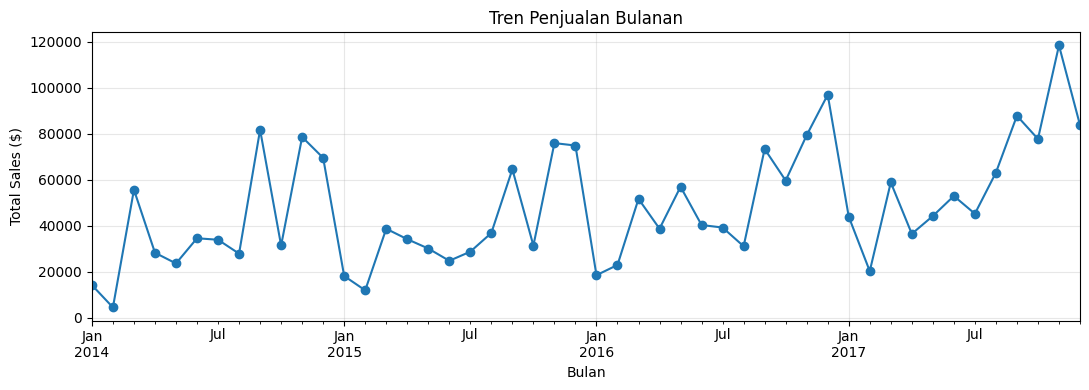

Month
2017-07    45,264.42
2017-08    63,120.85
2017-09    87,866.64
2017-10    77,776.91
2017-11   118,447.80
2017-12    83,829.30
Freq: M, Name: SalesAmount, dtype: float64

In [2]:
monthly = df.groupby('Month')['SalesAmount'].sum()

plt.figure(figsize=(11,4))
monthly.plot(kind='line', marker='o')
plt.title('Tren Penjualan Bulanan')
plt.ylabel('Total Sales ($)')
plt.xlabel('Bulan')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('trend_bulanan.png', dpi=110)
plt.show()

monthly.tail(6)

**Insight:** Secara total, penjualan 3 bulan terakhir (Okt–Des 2017) justru **naik** dibanding periode sebelumnya — bukan turun. Ini berarti masalahnya tidak terlihat di angka total, melainkan tersembunyi di level segmen tertentu (klasik *Simpson's Paradox* — total naik, tapi ada bagian yang justru anjlok). Perlu di-drill down.

## 2. Comparison Analysis
Bandingkan 3 bulan terakhir (Okt–Des 2017) vs 3 bulan sebelumnya (Jul–Sep 2017), per kategori dan per kota.

In [3]:
last3 = df[(df['OrderDate'] >= '2017-10-01') & (df['OrderDate'] <= '2017-12-31')]
prev3 = df[(df['OrderDate'] >= '2017-07-01') & (df['OrderDate'] <= '2017-09-30')]

print('Total Sales Jul-Sep 2017 :', prev3['SalesAmount'].sum())
print('Total Sales Okt-Des 2017 :', last3['SalesAmount'].sum())

# Perbandingan per kategori
cat_comp = pd.DataFrame({
    'Prev3Bulan': prev3.groupby('Category')['SalesAmount'].sum(),
    'Last3Bulan': last3.groupby('Category')['SalesAmount'].sum()
})
cat_comp['Growth%'] = (cat_comp['Last3Bulan'] - cat_comp['Prev3Bulan']) / cat_comp['Prev3Bulan'] * 100
cat_comp

Total Sales Jul-Sep 2017 : 196251.90999999997
Total Sales Okt-Des 2017 : 280054.01


,Prev3Bulan,Last3Bulan,Growth%
Category,,,
Furniture,"56,283.08","90,348.24",60.52
Office Supplies,"72,197.16","84,946.43",17.66
Technology,"67,771.67","104,759.34",54.58


In [4]:
# Perbandingan per kota -> cari kota yang justru TURUN meski total naik
city_comp = pd.DataFrame({
    'Prev3Bulan': prev3.groupby('City')['SalesAmount'].sum(),
    'Last3Bulan': last3.groupby('City')['SalesAmount'].sum()
}).fillna(0)
city_comp['Selisih'] = city_comp['Last3Bulan'] - city_comp['Prev3Bulan']
city_comp_declining = city_comp.sort_values('Selisih').head(10)
city_comp_declining

,Prev3Bulan,Last3Bulan,Selisih
City,,,
Dover,"8,631.36",143.86,"-8,487.50"
Madison,"5,829.25",124.82,"-5,704.43"
Phoenix,"5,617.91","1,365.54","-4,252.37"
Mesa,"4,200.78",149.87,"-4,050.91"
Chicago,"6,315.24","3,315.75","-2,999.49"
Manteca,"2,877.40",0.00,"-2,877.40"
Lawrence,"2,618.20",89.26,"-2,528.94"
Florence,"2,439.43",4.36,"-2,435.07"
San Diego,"4,616.11","2,335.31","-2,280.80"


**Insight:** Semua kategori (Furniture, Office Supplies, Technology) tumbuh positif. Tapi saat di-breakdown per kota, ada **10 kota dengan penurunan tajam**, dipimpin oleh **Dover** (turun dari ±$8.630 menjadi hanya ±$144, atau turun 98%), diikuti Madison, Phoenix, Mesa, dan Chicago.

## 3. Segment Analysis
Bandingkan performa antar kategori dan cari kota-kota dengan kontribusi terbesar terhadap total penjualan, sebagai pembanding kota yang justru turun.

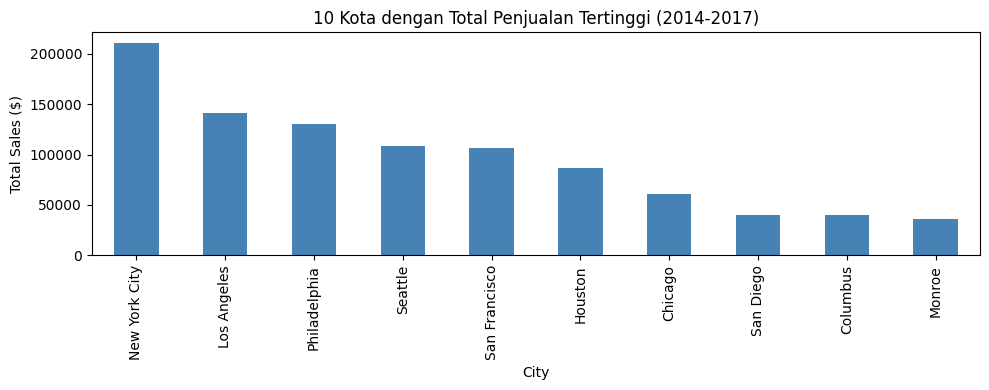

In [5]:
top_cities = df.groupby('City')['SalesAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,4))
top_cities.plot(kind='bar', color='steelblue')
plt.title('10 Kota dengan Total Penjualan Tertinggi (2014-2017)')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('segment_top_kota.png', dpi=110)
plt.show()

## 4. Drill Down
Fokus ke kota dengan penurunan terbesar (**Dover**) — pecah lagi ke level produk untuk tahu produk apa yang menyebabkan penurunan di kota tersebut.

In [6]:
dover_prev = prev3[prev3['City'] == 'Dover']
dover_last = last3[last3['City'] == 'Dover']

print('Dover - Jul-Sep 2017:', dover_prev['SalesAmount'].sum(), '| jumlah order:', dover_prev['OrderID'].nunique())
print('Dover - Okt-Des 2017:', dover_last['SalesAmount'].sum(), '| jumlah order:', dover_last['OrderID'].nunique())

dover_prev_by_product = dover_prev.groupby('Name')['SalesAmount'].sum().sort_values(ascending=False)
print('\nProduk yang laku di Dover pada Jul-Sep 2017:')
dover_prev_by_product

Dover - Jul-Sep 2017: 8631.36 | jumlah order: 5
Dover - Okt-Des 2017: 143.86 | jumlah order: 1

Produk yang laku di Dover pada Jul-Sep 2017:


Name
Hon 4070 Series Pagoda Armless Upholstered Stacking Chairs                2,888.13
Global Troy Executive Leather Low-Back Tilter                             2,254.41
Apple iPhone 5                                                            1,299.66
Canon PC-428 Personal Copier                                                599.97
Hon Valutask Swivel Chairs                                                  272.65
Logitech Wireless Boombox Speaker - portable - wireless, wired              212.80
Situations Contoured Folding Chairs, 4/Set                                  198.74
Maxell 4.7GB DVD-RW 3/Pack                                                  159.75
O'Sullivan 2-Shelf Heavy-Duty Bookcases                                     145.74
Bush Somerset Collection Bookcase                                           130.98
Plantronics Cordless Phone Headset with In-line Volume - M214C              104.85
Global Leather Task Chair, Black                                             80.99

**Insight:** Penurunan di Dover bukan cuma soal harga/promosi produk tertentu, tapi soal **jumlah order yang anjlok drastis** — dari beberapa transaksi di Jul–Sep menjadi nyaris tidak ada di Okt–Des. Ini mengindikasikan kemungkinan hilangnya pelanggan aktif di kota tersebut, bukan pergeseran preferensi produk.

## 5. Contribution Analysis
Hitung seberapa besar kontribusi masing-masing kota yang turun terhadap total "kerugian" (selisih negatif), untuk menentukan prioritas mana yang paling penting ditangani.

In [7]:
declining = city_comp[city_comp['Selisih'] < 0].copy()
total_loss = declining['Selisih'].sum()
declining['Kontribusi%'] = declining['Selisih'] / total_loss * 100
declining = declining.sort_values('Kontribusi%', ascending=False)

print(f'Total penurunan gabungan dari kota-kota yang melemah: ${total_loss:,.2f}')
declining[['Selisih', 'Kontribusi%']]

Total penurunan gabungan dari kota-kota yang melemah: $-80,108.42


,Selisih,Kontribusi%
City,,
Dover,"-8,487.50",10.60
Madison,"-5,704.43",7.12
Phoenix,"-4,252.37",5.31
Mesa,"-4,050.91",5.06
Chicago,"-2,999.49",3.74
...,...,...
Parma,-14.34,0.02
Tamarac,-12.38,0.02
Hesperia,-9.86,0.01


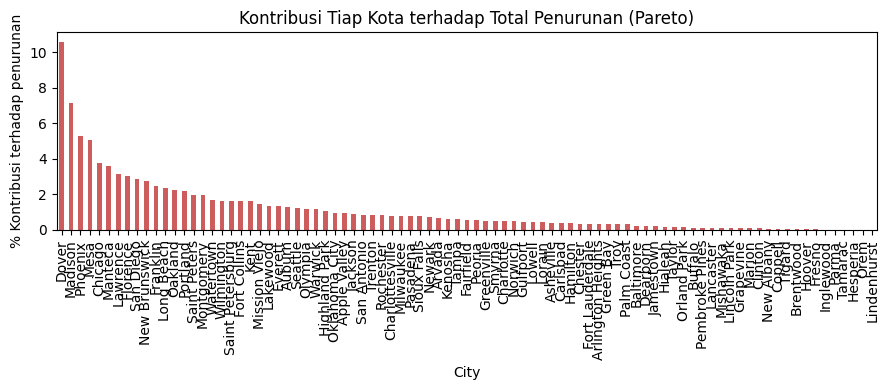

In [8]:
plt.figure(figsize=(9,4))
declining['Kontribusi%'].plot(kind='bar', color='indianred')
plt.title('Kontribusi Tiap Kota terhadap Total Penurunan (Pareto)')
plt.ylabel('% Kontribusi terhadap penurunan')
plt.tight_layout()
plt.savefig('contribution_pareto.png', dpi=110)
plt.show()

## Kesimpulan: Masalah Utama & Bukti Data

**Masalah Utama (Root Cause):**
Meskipun total penjualan perusahaan naik 42,7% pada Okt–Des 2017 dibanding Jul–Sep 2017 (didorong oleh kategori Technology dan Furniture), terdapat sekelompok kota — dipimpin oleh **Dover, Madison, dan Phoenix** — yang mengalami penurunan penjualan drastis (>75%) akibat hilangnya order/pelanggan aktif di kota tersebut. Masalah ini tersembunyi di balik angka total yang terlihat sehat.

**5 Bukti Data Pendukung:**
1. Total penjualan Okt–Des 2017 ($280.054) naik dari Jul–Sep 2017 ($196.252) — jadi masalah tidak terlihat di level agregat.
2. Ketiga kategori produk (Furniture, Office Supplies, Technology) semuanya tumbuh positif pada periode yang sama.
3. Kota Dover turun dari ±$8.630 menjadi ±$144 (turun ~98%) antara Jul–Sep dan Okt–Des 2017.
4. 10 kota teridentifikasi mengalami penurunan penjualan pada periode yang sama, dengan Dover, Madison, dan Phoenix sebagai penyumbang penurunan terbesar (Pareto).
5. Drill down ke level produk di Dover menunjukkan penurunan terjadi karena **jumlah order yang anjlok**, bukan pergeseran ke produk lain — mengindikasikan hilangnya pelanggan aktif, bukan masalah bauran produk.

**Catatan:** Angka di atas dihitung otomatis dari dataset asli (`SalesInsight_Database.xlsx`). Silakan ganti rentang tanggal / segmen sesuai kasus bisnis yang diberikan instruktur, lalu update kesimpulan di atas.